In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle

In [2]:
fake = pd.read_csv('../dataset/Fake.csv')
real = pd.read_csv('../dataset/True.csv')

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
fake.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 733.9 KB


In [6]:
fake.shape

(23481, 4)

In [7]:
real.shape

(21417, 4)

In [8]:
#Adding label to know the fake and real data as ml model doesn't understand "fake" and "real"
fake['label']=0  #0 means fake
real['label']=1  #1 means real

In [9]:
##Combing both the dataset
df=pd.concat([fake,real]).reset_index(drop=True)

In [10]:
#remove empty rows
df.dropna(inplace=True)

In [11]:
# Keep only text and label columns
df = df[['text', 'label']]

In [12]:
print("Combined dataset shape:", df.shape)
print("\nLabel counts:")
print(df['label'].value_counts())


Combined dataset shape: (44898, 2)

Label counts:
label
0    23481
1    21417
Name: count, dtype: int64


### EDA (Exploratory Data Analysis)



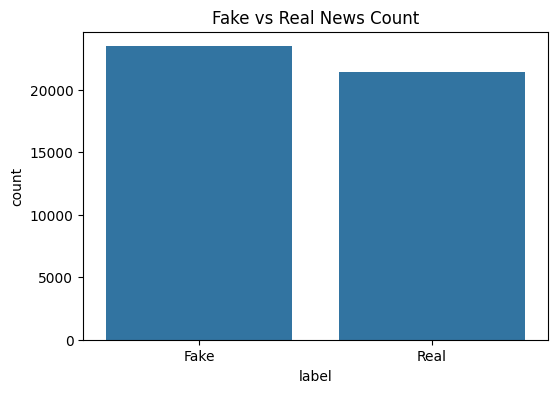

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Fake vs Real News Count')
plt.xticks([0,1], ['Fake', 'Real'])
plt.show()

In [14]:
# Check average text length
df['text_length'] = df['text'].apply(len)
print("Average text length:")
print(df.groupby('label')['text_length'].mean())

Average text length:
label
0    2547.396235
1    2383.278517
Name: text_length, dtype: float64


### Data Cleaning


In [15]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [16]:
# Downloading Stopwords
#Stopwords ---> Stopwords are very common words that have no real meaning for our model.Example:is,the,are,was,were etc

nltk.download('stopwords')

# Initializing Stemmer
# Stemmer converts words to their root/base form:running->run,elcection->elect,elected->elect

ps=PorterStemmer()

# Load stopwords ONCE outside the function
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:

def clean_text(text):
    #1.Remove URLs

    text=re.sub(r'https?://\S+|www.\S+', '', text)

    #2.Remove special characters and numbers
    text=re.sub(r'[^a-zA-Z]', ' ', text)

    # 3.Convert to lowercase
    text = text.lower()
    
    # 4. Split into words
    words = text.split()

    # 5. Remove stopwords and apply stemming
    words = [ps.stem(word) for word in words 
              if word not in stop_words]
    
    # 6. Join back to string
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
print("Cleaning done! ")
print(df['clean_text'].head(2))



Cleaning done! 
0    donald trump wish american happi new year leav...
1    hous intellig committe chairman devin nune go ...
Name: clean_text, dtype: str


### Feature Engineering (TF-IDF)->converting our text into numbers

* TF-IDF stands for:

- TF = Term Frequency
- IDF = Inverse Document Frequency

** TF (Term Frequency):

a. How many times a word appears in ONE article:

   ->>> Article: "trump trump president trump"

    ->>> TF of "trump" = 3/4 = 0.75

** IDF (Inverse Document Frequency):


b. How rare/important a word is across ALL articles:

  ->>> "trump" appears in many articles = less important
   
   ->>>"impeachment" appears in few articles = more important

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
# Convert text to numbers
X = tfidf.fit_transform(df['clean_text'])
y = df['label']
print("Feature matrix shape:", X.shape)
print("Each article is now represented as", X.shape[1], "numbers!")

Feature matrix shape: (44898, 5000)
Each article is now represented as 5000 numbers!


In [19]:
df.head(15)

,text,label,text_length,clean_text
0,Donald Trump just couldn t wish all Americans ...,0,2893,donald trump wish american happi new year leav...
1,House Intelligence Committee Chairman Devin Nu...,0,1898,hous intellig committe chairman devin nune go ...
2,"On Friday, it was revealed that former Milwauk...",0,3597,friday reveal former milwauke sheriff david cl...
3,"On Christmas day, Donald Trump announced that ...",0,2774,christma day donald trump announc would back w...
4,Pope Francis used his annual Christmas Day mes...,0,2346,pope franci use annual christma day messag reb...
5,The number of cases of cops brutalizing and ki...,0,1741,number case cop brutal kill peopl color seem s...
6,Donald Trump spent a good portion of his day a...,0,2166,donald trump spent good portion day golf club ...
7,In the wake of yet another court decision that...,0,2224,wake yet anoth court decis derail donald trump...
8,Many people have raised the alarm regarding th...,0,2772,mani peopl rais alarm regard fact donald trump...
9,Just when you might have thought we d get a br...,0,1644,might thought get break watch peopl kiss donal...


In [20]:
df.shape

(44898, 4)

In [21]:
X.shape

(44898, 5000)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print(f"\nTraining articles: {X_train.shape[0]}")
print(f"Testing articles: {X_test.shape[0]}")

Training size: (35918, 5000)
Testing size: (8980, 5000)

Training articles: 35918
Testing articles: 8980



### Train the Model

In [23]:
# PassiveAggressiveClassifier Model
# Question comes in:
#     ↓
# Model answers it

# If CORRECT ✅
# → "I knew it!" 
# → Stay PASSIVE (don't change anything)

# If WRONG 
# → "Oh no!"
# → Be AGGRESSIVE (immediately fix the mistake)
# → Update itself

In [24]:
from sklearn.linear_model import PassiveAggressiveClassifier
# Initialize model
model = PassiveAggressiveClassifier(max_iter=50)
# Train the model
print("Training started...")
model.fit(X_train, y_train)
print("Training done! ")


Training started...


e:\Projects\python-with-ml\machine-learning-deepa-fake-news-detection\venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Training done! 



###  Check Accuracy

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Make predictions on test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 99.38%


### Confusion Matrix

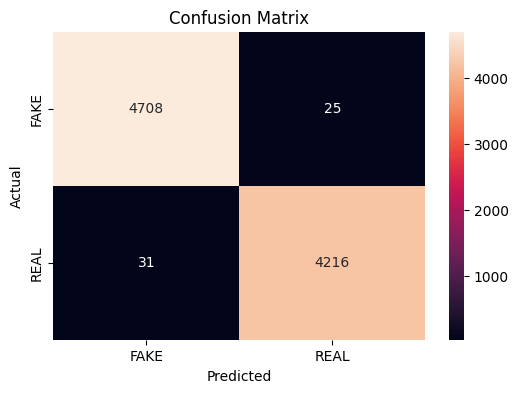

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Classification Report


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, 
      target_names=['FAKE', 'REAL']))

              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4733
        REAL       0.99      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [28]:
import pickle

# Save model
pickle.dump(model, open('../ml_model/model.pkl', 'wb'))

# Save vectorizer
pickle.dump(tfidf, open('../ml_model/vectorizer.pkl', 'wb'))

print("Model saved as model.pkl ")
print("Vectorizer saved as vectorizer.pkl")

Model saved as model.pkl 
Vectorizer saved as vectorizer.pkl
